## Extension Analysis Work (on-going)

In [44]:
from tabulate import tabulate
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

pd.set_option('display.max_rows', None)  
pd.set_option('display.max_columns', None)  
pd.set_option('display.expand_frame_repr', False)

In [45]:
def joules_to_kwh(joules):
    return float(joules) / 3600000

def load_philipp_data(cluster, workflow, runs):
    processed = {}

    for run in range(1, runs+1):
        with open(f'nxf-experiments/{cluster}-cluster/{workflow}/{run}/wf_data.csv') as file:
            stripped_lines = [line.rstrip().split(',') for line in file.readlines()]
            data = stripped_lines[1:]

        pkg = data[0][11]
        dram = data[0][12]
        total = data[0][13]

        processed[run] = {}
        processed[run]['pkg'] = joules_to_kwh(pkg)
        processed[run]['dram'] = joules_to_kwh(dram)
        processed[run]['total'] = joules_to_kwh(total)
    
    return processed


def load_data_totals(cluster, workflow, runs):
    processed = {}

    for run in range(1, runs+1):
        proc_data = pd.read_csv(f'nxf-experiments/{cluster}-cluster/{workflow}/{run}/trace.csv', header=0)
        processed[run] = {}
        processed[run]['read'] = proc_data['read_bytes'].sum() / 1073741824  # convert from B to GiB
        processed[run]['write'] = proc_data['write_bytes'].sum() / 1073741824  # convert from B to GiB

    return processed


def load_philipp_total_energy(cluster, workflow, runs):
    processed = {}
        
    for run in range(1, runs+1):
        with open(f'nxf-experiments/{cluster}-cluster/{workflow}/{run}/task_data.md') as file:
            lines = [line.strip() for line in file.readlines()]

        final = lines[-1].split(': ')[1][:-6]

        processed[run] = {}
        processed[run]['pkg'] = None
        processed[run]['dram'] = None
        processed[run]['total'] = joules_to_kwh(final)
    
    return processed

In [46]:
# Functions to parse rapl data
def load_workflow_rapl_readings(cluster, workflow):
    with open(f'nxf-experiments/{cluster}-cluster/{workflow}-runs.csv', 'r') as file:
        data = [line.strip().split(',') for line in file.readlines()]
    
    return data[1:]

gu_socket = {'rnaseq': 'both', 'chipseq': 'both', 'nanoseq': 'both', 'atacseq': 'both'}

def process_rapl_data(data, gu=False, wf=''):
    processed = {}
    run = 1

    for row in data:
        if gu:
            idle_dram_2 = float(row[14])
            total_dram_2 = float(row[11]) 
            active_dram_2 = float(row[17])
            idle_dram_1 = float(row[5])
            total_dram_1 = float(row[2])
            active_dram_1 = float(row[8])
            rapl_pkg = float(row[7]) + float(row[16])

            if idle_dram_1 + idle_dram_2 > total_dram_1 + total_dram_2:
                rapl_mem = total_dram_1 + total_dram_2
            else:
                rapl_mem = active_dram_1 + active_dram_2
            rapl_total = rapl_pkg + rapl_mem
        else:
            rapl_pkg = float(row[7])
            active_dram = float(row[8])
            idle_dram = float(row[5])
            total_dram = float(row[2])

            if idle_dram > total_dram:
                rapl_mem = total_dram
            else:
                rapl_mem = active_dram

            rapl_total = rapl_pkg + rapl_mem

        processed[run] = {}
        processed[run]['pkg'] = rapl_pkg
        processed[run]['dram'] = rapl_mem
        processed[run]['total'] = rapl_total
        run += 1

    return processed

In [47]:
# Functions to parse ichnos data
def load_ichnos_summary_file(summary_file):
    with open(summary_file, 'r') as file:
        raw = [line.strip() for line in file.readlines()]

    cpu = float(raw[7].split(':')[1].strip()[:-3])
    task_mem = float(raw[9].split(':')[1].strip()[:-3])
    node_mem = float(raw[15].split(':')[1].strip()[:-3])

    return (cpu, task_mem, node_mem)

def load_ichnos_data(cluster, workflow, runs, strategy):
    workflow_path = f'nxf-experiments/{cluster}-cluster/{workflow}/ichnos'
    data = {}

    for run in range(1, runs + 1):
        data[run] = {}
        (cpu, task_mem, node_mem) = load_ichnos_summary_file(f'{workflow_path}/{cluster}-{workflow}-{run}-1-{strategy}-summary.txt')
        data[run]['pkg'] = cpu
        data[run]['mem_dyn'] = task_mem
        data[run]['mem_stat'] = node_mem 
        data[run]['total'] = cpu + task_mem + node_mem

    return data

In [48]:
# Generic functions
def get_error(experimental, actual):
    return round((abs(experimental - actual) / actual) * 100, 2)

In [49]:
def load_nxf_trace(cluster, workflow, run):
    filepath = f'nxf-experiments/{cluster}-cluster/{workflow}/{run}/trace.csv'
    nxf_trace = pd.read_csv(filepath, header=0)
    start_ms = min(nxf_trace['start'])
    end_ms = max(nxf_trace['complete'])
    runtime = (end_ms - start_ms) / 1000 / 60  # mins
    start_day = datetime.fromtimestamp(start_ms / 1000).strftime('%Y-%m-%d')
    end_day = datetime.fromtimestamp(end_ms / 1000).strftime('%Y-%m-%d')
    nxf_trace['memory'] /= 1073741824
    print(f'{cluster} {workflow} {run} took {runtime:.0f}m on {start_day} to {end_day}')
    return (nxf_trace, runtime)

In [50]:
def plot_task_length_fig(vals, workflow):
    plt.figure(figsize=(6,2))
    plt.violinplot(vals['realtime'] / 1000 / 60, vert=False, showmedians=True, showextrema=True)
    plt.title(workflow)
    plt.xlabel('time (m)')
    plt.xlim(0,60)
    plt.show()

In [51]:
rapl_data = {'hu': {}, 'gu': {}}
rapl_data['hu']['rnaseq'] = process_rapl_data(load_workflow_rapl_readings('hu', 'rnaseq'))
rapl_data['hu']['chipseq'] = process_rapl_data(load_workflow_rapl_readings('hu', 'chipseq'))
rapl_data['hu']['atacseq'] = process_rapl_data(load_workflow_rapl_readings('hu', 'atacseq'))
rapl_data['hu']['rangeland'] = process_rapl_data(load_workflow_rapl_readings('hu', 'rangeland'))
rapl_data['hu']['nanoseq'] = process_rapl_data(load_workflow_rapl_readings('hu', 'nanoseq'))
rapl_data['hu']['sarek'] = process_rapl_data(load_workflow_rapl_readings('hu', 'sarek'))

rapl_data['gu']['atacseq'] = process_rapl_data(load_workflow_rapl_readings('gu', 'atacseq'), True, 'atacseq')
rapl_data['gu']['chipseq'] = process_rapl_data(load_workflow_rapl_readings('gu', 'chipseq'), True, 'chipseq')
rapl_data['gu']['nanoseq'] = process_rapl_data(load_workflow_rapl_readings('gu', 'nanoseq'), True, 'nanoseq')
rapl_data['gu']['rnaseq'] = process_rapl_data(load_workflow_rapl_readings('gu', 'rnaseq'), True, 'rnaseq')

ichnos_data = {'hu': {}, 'gu': {}}
ichnos_data['hu']['rnaseq'] = load_ichnos_data('hu', 'rnaseq', len(rapl_data['hu']['rnaseq']), 'schedutil_linear')
ichnos_data['hu']['chipseq'] = load_ichnos_data('hu', 'chipseq', len(rapl_data['hu']['chipseq']), 'schedutil_linear')
ichnos_data['hu']['atacseq'] = load_ichnos_data('hu', 'atacseq', len(rapl_data['hu']['atacseq']), 'performance_linear')
ichnos_data['hu']['rangeland'] = load_ichnos_data('hu', 'rangeland', len(rapl_data['hu']['rangeland']), 'schedutil_linear')
ichnos_data['hu']['nanoseq'] = load_ichnos_data('hu', 'nanoseq', len(rapl_data['hu']['nanoseq']), 'performance_linear')
ichnos_data['hu']['sarek'] = load_ichnos_data('hu', 'sarek', len(rapl_data['hu']['sarek']), 'schedutil_linear')

ichnos_data['gu']['rnaseq'] = load_ichnos_data('gu', 'rnaseq', len(rapl_data['gu']['rnaseq']), 'ondemand_linear')
ichnos_data['gu']['atacseq'] = load_ichnos_data('gu', 'atacseq', len(rapl_data['gu']['atacseq']), 'ondemand_linear')
ichnos_data['gu']['chipseq'] = load_ichnos_data('gu', 'chipseq', len(rapl_data['gu']['chipseq']), 'ondemand_linear')
ichnos_data['gu']['nanoseq'] = load_ichnos_data('gu', 'nanoseq', len(rapl_data['gu']['nanoseq']), 'ondemand_linear')

io_data = {'hu': {}, 'gu': {}}
io_data['hu']['rnaseq'] = load_data_totals('hu', 'rnaseq', 3)
io_data['hu']['chipseq'] = load_data_totals('hu', 'chipseq', 3)
io_data['hu']['atacseq'] = load_data_totals('hu', 'atacseq', 3)
io_data['hu']['rangeland'] = load_data_totals('hu', 'rangeland', 3)
io_data['hu']['nanoseq'] = load_data_totals('hu', 'nanoseq', 3)
io_data['hu']['sarek'] = load_data_totals('hu', 'sarek', 3)

io_data['gu']['rnaseq'] = load_data_totals('gu', 'rnaseq', 3)
io_data['gu']['chipseq'] = load_data_totals('gu', 'chipseq', 3)
io_data['gu']['atacseq'] = load_data_totals('gu', 'atacseq', 3)
io_data['gu']['nanoseq'] = load_data_totals('gu', 'nanoseq', 3)

table_data = []
table_head = ['cluster', 'workflow', 'run', 'ichnos_pkg', 'rapl_pkg', 'err_pkg', 'i_mem_dyn', 'i_mem_stat', 'i_mem', 'rapl_mem', 'err_mem', 'ichnos_total', 'rapl_total', 'err_total']

for cluster in ['hu', 'gu']:
    for workflow in rapl_data[cluster].keys():
        for run in range(1, len(rapl_data[cluster][workflow].keys()) + 1):
            rapl_entry = rapl_data[cluster][workflow][run]
            rapl_pkg = rapl_entry['pkg']
            rapl_dram = rapl_entry['dram']
            ichnos_entry = ichnos_data[cluster][workflow][run]
            ichnos_pkg = ichnos_entry['pkg']
            ichnos_mem_dyn = ichnos_entry['mem_dyn']
            ichnos_mem_stat = ichnos_entry['mem_stat']
            ichnos_dram = ichnos_mem_dyn + ichnos_mem_stat
            io_entry = io_data[cluster][workflow][run]
            table_data.append([cluster, workflow, run, round(ichnos_pkg, 2), round(rapl_pkg, 2), get_error(ichnos_pkg, rapl_pkg), round(ichnos_mem_dyn, 2), round(ichnos_mem_stat, 2), round(ichnos_dram, 2), round(rapl_dram, 2), get_error(ichnos_dram, rapl_dram), round(ichnos_entry['total'], 2), round(rapl_entry['total'], 2), get_error(ichnos_entry['total'], rapl_entry['total'])])

all_data = pd.DataFrame(table_data, columns=table_head)

todo for evaluation?
- make estimation with nf-co2footprint plugin script for comparison
- run ichnos with all new features for full output dataset

In [52]:
rows_hu = all_data[all_data['cluster'] == 'hu'].reset_index()
median_rows_hu = rows_hu.sort_values(['workflow', 'rapl_total']).groupby('workflow').nth(1)
print(median_rows_hu.sort_values(['rapl_total']))

    index cluster   workflow  run  ichnos_pkg  rapl_pkg  err_pkg  i_mem_dyn  i_mem_stat  i_mem  rapl_mem  err_mem  ichnos_total  rapl_total  err_total
13     13      hu    nanoseq    2        0.34      0.36     6.69       0.02        0.08   0.10      0.18    45.49          0.43        0.54      19.41
8       8      hu    atacseq    3        0.48      0.47     0.69       0.03        0.11   0.14      0.16    11.54          0.62        0.63       2.39
9       9      hu  rangeland    1        1.55      2.00    22.32       0.24        0.37   0.61      0.48    27.21          2.16        2.48      12.75
1       1      hu     rnaseq    2        1.71      1.99    14.02       0.21        0.36   0.56      0.53     5.68          2.27        2.52       9.85
4       4      hu    chipseq    2        3.52      4.11    14.44       0.42        0.74   1.16      1.05    10.52          4.68        5.16       9.36
16     16      hu      sarek    2        3.84      4.38    12.33       0.22        0.75   0.97

In [53]:
rows_gu = all_data[all_data['cluster'] == 'gu'].reset_index()
median_rows_gu = rows_gu.sort_values(['workflow', 'rapl_total']).groupby('workflow').nth(1)
print(median_rows_gu.sort_values(['rapl_total']))

   index cluster workflow  run  ichnos_pkg  rapl_pkg  err_pkg  i_mem_dyn  i_mem_stat  i_mem  rapl_mem  err_mem  ichnos_total  rapl_total  err_total
6     24      gu  nanoseq    1        0.58      0.58     0.91       0.12        0.20   0.32      0.12   153.66          0.90        0.70      28.00
2     20      gu  atacseq    3        0.92      0.90     2.05       0.21        0.31   0.51      0.17   195.84          1.43        1.08      33.32
9     27      gu   rnaseq    1        0.97      0.96     0.96       0.20        0.33   0.53      0.96    44.71          1.51        1.93      21.87
5     23      gu  chipseq    3        1.31      1.31     0.11       0.28        0.43   0.71      1.31    45.50          2.02        2.61      22.69


In [54]:
hu_nanoseq, hu_nanoseq_time = load_nxf_trace('hu', 'nanoseq', 2)
hu_atacseq, hu_atacseq_time = load_nxf_trace('hu', 'atacseq', 3)
hu_rangeland, hu_rangeland_time = load_nxf_trace('hu', 'rangeland', 1)
hu_rnaseq, hu_rnaseq_time = load_nxf_trace('hu', 'rnaseq', 2)
hu_chipseq, hu_chipseq_time = load_nxf_trace('hu', 'chipseq', 2)
hu_sarek, hu_sarek_time = load_nxf_trace('hu', 'sarek', 2)

hu nanoseq 2 took 90m on 2026-03-06 to 2026-03-06
hu atacseq 3 took 110m on 2026-02-23 to 2026-02-23
hu rangeland 1 took 253m on 2025-11-22 to 2025-11-23
hu rnaseq 2 took 251m on 2025-11-18 to 2025-11-18
hu chipseq 2 took 601m on 2025-11-19 to 2025-11-20
hu sarek 2 took 514m on 2026-02-08 to 2026-02-08


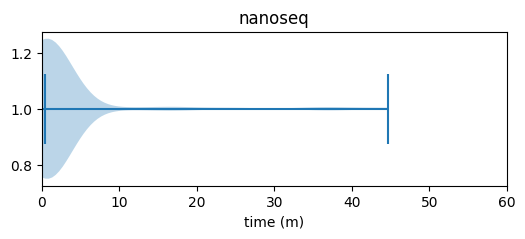

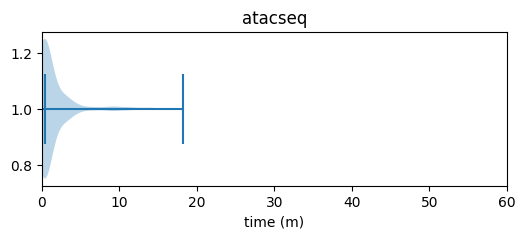

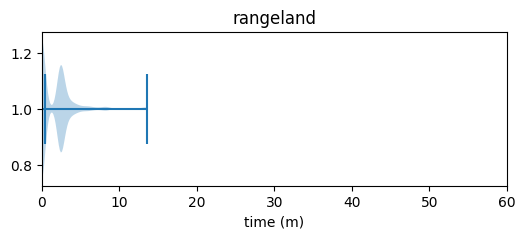

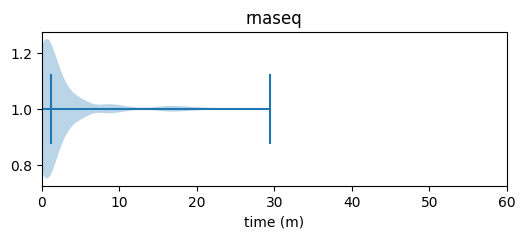

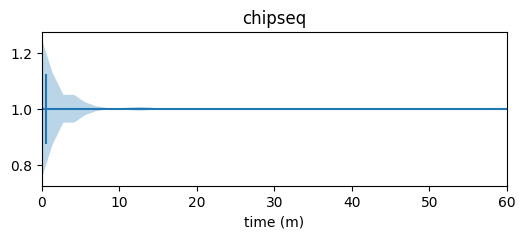

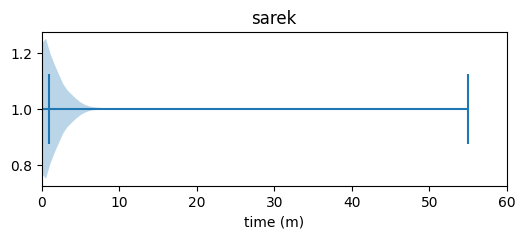

In [55]:
plot_task_length_fig(hu_nanoseq, 'nanoseq')
plot_task_length_fig(hu_atacseq, 'atacseq')
plot_task_length_fig(hu_rangeland, 'rangeland')
plot_task_length_fig(hu_rnaseq, 'rnaseq')
plot_task_length_fig(hu_chipseq, 'chipseq')
plot_task_length_fig(hu_sarek, 'sarek')

In [56]:
gu_nanoseq, gu_nanoseq_time = load_nxf_trace('gu', 'nanoseq', 1)
gu_atacseq, gu_atacseq_time = load_nxf_trace('gu', 'atacseq', 3)
gu_rnaseq, gu_rnaseq_time = load_nxf_trace('gu', 'rnaseq', 1)
gu_chipseq, gu_chipseq_time = load_nxf_trace('gu', 'chipseq', 3)

gu nanoseq 1 took 217m on 2026-02-11 to 2026-02-11
gu atacseq 3 took 251m on 2026-02-28 to 2026-02-28
gu rnaseq 1 took 253m on 2026-01-29 to 2026-01-29
gu chipseq 3 took 311m on 2026-01-29 to 2026-01-29


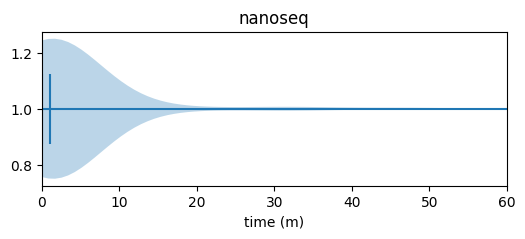

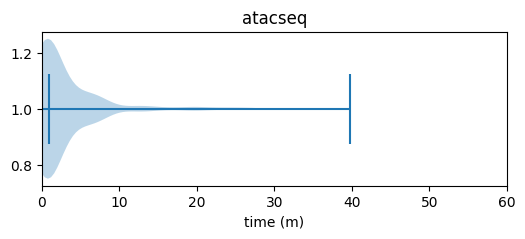

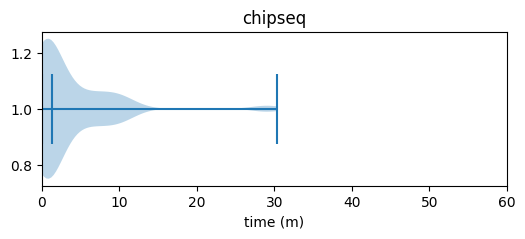

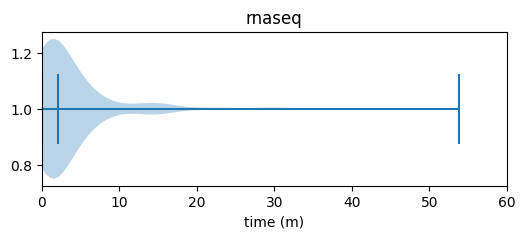

In [57]:
plot_task_length_fig(gu_nanoseq, 'nanoseq')
plot_task_length_fig(gu_atacseq, 'atacseq')
plot_task_length_fig(gu_chipseq, 'chipseq')
plot_task_length_fig(gu_rnaseq, 'rnaseq')